# Pipeline Triple MRD — FlowSOM × 3 Méthodes

## Objectif
Calculer la MRD (Maladie Résiduelle Détectable) en LAM/AML à partir d'un ou plusieurs fichiers FCS pathologiques, en appliquant **3 méthodes en parallèle** sur les mêmes données mappées sur le MST de référence NBM :

| Méthode | Logique | Référence |
|---------|---------|-----------|
| **M1** — Δ Métaclusters | Proportion patient > 2× NBM par métacluster | ELN 2022 (fold-change) |
| **M2** — Distance MST | Nœuds SOM déviants (distance euclidienne patient ↔ NBM > μ + k·σ) | Approche distancielle |
| **M3** — Mapping Pop. | Nœuds « Unknown » après mapping M12_cosine_prior (Section 10) | Pipeline principal |

## Architecture du module `mrd_pipeline.py`
```
NBMReference.build()           ← construire le modèle NBM (1 seule fois)
  ↓
run_mrd_pipeline_for_patient() ← 1 patient = 1 FCS
  ├── preprocess_fcs()          ← gating + transformation + alignement marqueurs
  ├── map_patient_to_nbm()      ← mapping SOM patient → nœuds NBM
  ├── mrd_method_1()            ← Δ métaclusters
  ├── mrd_method_2()            ← distances euclidiennes
  ├── mrd_method_3()            ← mapping populations
  └── select_best_mrd_method()  ← sélection + flag divergence
  ↓
run_mrd_batch()                ← cohorte entière, sauvegarde HTML + JSON + CSV
```

## Hypothèses de nommage
- Les **FCS NBM** sont dans un dossier dédié (`HEALTHY_FOLDER`).
- Les **CSV de référence MFI** (Méthode 3) sont dans `Data/Ref MFI/`.
- Les **FCS patients** sont dans `PATHOLOGICAL_FOLDER` (1 fichier = 1 patient).
- Si le modèle NBM a **déjà été calculé** dans le notebook principal, utiliser `NBMReference.build_from_precomputed()` pour éviter de le recalculer.

---
*Auteur : Florian Magne · Version 1.0 · Mars 2026*

In [12]:
## Cellule 1 — Vérification des dépendances
import importlib.util

REQUIRED = ["flowsom", "anndata", "flowio", "numpy", "pandas", "scipy", "sklearn", "matplotlib"]
OPTIONAL  = ["flowkit", "fcswrite"]

print("=== Dépendances requises ===")
for pkg in REQUIRED:
    spec = importlib.util.find_spec(pkg.replace("-", "_"))
    status = "OK" if spec else "MANQUANT"
    print(f"  {pkg:<20} {status}")

print("\n=== Dépendances optionnelles ===")
for pkg in OPTIONAL:
    spec = importlib.util.find_spec(pkg.replace("-", "_"))
    status = "OK" if spec else "non installe"
    print(f"  {pkg:<20} {status}")

=== Dépendances requises ===
  flowsom              OK
  anndata              OK
  flowio               OK
  numpy                OK
  pandas               OK
  scipy                OK
  sklearn              OK
  matplotlib           OK

=== Dépendances optionnelles ===
  flowkit              OK
  fcswrite             OK


In [13]:
## Cellule 2 — Imports + chargement du module mrd_pipeline

import sys
import os
from pathlib import Path

# ---- Chemin vers le module mrd_pipeline ----
MODULE_DIR = Path(r"C:\Users\flo40\Documents\FlowSomCode")
if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))

from mrd_pipeline import (
    DEFAULT_PARAMS,
    NBMReference,
    preprocess_fcs,
    mrd_method_1,
    mrd_method_2,
    mrd_method_3,
    select_best_mrd_method,
    run_mrd_pipeline_for_patient,
    run_mrd_batch,
    export_patient_json,
    export_patient_html,
    export_kaluza_csv,
)

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

print("Module mrd_pipeline charge avec succes.")
print(f"Parametres par defaut disponibles : {list(DEFAULT_PARAMS.keys())}")


Module mrd_pipeline charge avec succes.
Parametres par defaut disponibles : ['healthy_folder', 'pathological_folder', 'compare_mode', 'apply_pregating', 'gating_mode', 'mode_blastes', 'gate_debris', 'debris_min_pct', 'debris_max_pct', 'gate_doublets', 'ratio_min', 'ratio_max', 'gate_cd45', 'cd45_pct', 'filter_blasts', 'cd34_pct', 'ssc_filter', 'ssc_max_pct', 'transform', 'cofactor', 'apply_to_scatter', 'exclude_scatter', 'exclude_markers', 'xdim', 'ydim', 'rlen', 'n_clusters', 'seed', 'auto_cluster', 'min_k', 'max_k', 'n_bootstrap', 'sample_boot', 'min_stability', 'w_stability', 'w_silhouette', 'apply_marker_filtering', 'keep_area', 'keep_height', 'gmm_max_samples', 'ransac_r2_threshold', 'mrd1_fold_change', 'mrd1_min_events', 'mad_allowed', 'mrd2_ratio_threshold', 'mrd2_min_cells_per_cluster', 'mrd3_mapping_method', 'mrd3_unknown_mode', 'mrd3_hard_limit_factor', 'm3_benchmark_methods', 'm3_log_benchmark', 'divergence_threshold_pct', 'output_dir']


In [ ]:
## Cellule 3 — Configuration des chemins et paramètres
#
# Utilise DEFAULT_PARAMS comme base et surcharge uniquement ce qui diffère.
# TOUS les paramètres du panneau de configuration (widgets FlowSOM_Analysis_Pipeline)
# sont disponibles via DEFAULT_PARAMS et peuvent être surchargés ici.

# ============================================================
# ADAPTER À VOTRE ENVIRONNEMENT
# ============================================================

# Dossier contenant les FCS normaux (NBM = Normal Bone Marrow)
NBM_FOLDER = Path(r"C:\Users\flo40\Documents\FlowSomCode\Data\PoolNBM")

# Dossier contenant les FCS pathologiques patients
PATHOLOGICAL_FOLDER = Path(r"C:\Users\flo40\Documents\FlowSomCode\Data\Patient")

# Dossier CSV de référence MFI populations (optionnel, pour Méthode 3)
REF_MFI_CSV_FOLDER = Path(r"C:\Users\flo40\Documents\FlowSomCode\Data\Ref MFI")

# Dossier de sortie pour les rapports HTML/JSON/CSV
OUTPUT_DIR = Path(r"C:\Users\flo40\Documents\FlowSomCode\output\mrd_reports")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# ★ AUTO-CLUSTERING — PARAMÈTRE PRINCIPAL
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#   False → utilise N_CLUSTERS ci-dessous (fixe, rapide)
#   True  → pipeline 3 phases : silhouette codebook (Phase 1)
#            + stabilité bootstrap ARI (Phase 2)
#            + score composite pondéré (Phase 3)
#   ⚠️ True peut prendre plusieurs minutes selon n_bootstrap.
# ============================================================
AUTO_CLUSTER = False            # ← CHANGER ICI

# Nombre de métaclusters si AUTO_CLUSTER = False
N_CLUSTERS = 7                  # ELN 2022 recommande 7–10 pour LAM

# Plage de k testée si AUTO_CLUSTER = True
MIN_CLUSTERS_AUTO = 5
MAX_CLUSTERS_AUTO = 35

# Bootstrap (Phase 2)
N_BOOTSTRAP        = 10         # Nombre de runs par k (↑ = plus fiable mais plus lent)
SAMPLE_BOOT        = 20000      # Cellules par run bootstrap (sous-ensemble fixe)
MIN_STABILITY      = 0.75       # Seuil ARI minimal ELN (< → pénalisé)
W_STABILITY        = 0.65       # Poids stabilité dans le score composite
W_SILHOUETTE       = 0.35       # Poids silhouette   (w_stability + w_silhouette = 1.0)

# ============================================================
# PARAMÈTRES DU PIPELINE — Extension de DEFAULT_PARAMS
# ============================================================
PARAMS = DEFAULT_PARAMS.copy()
PARAMS.update({
    # ── Section 1 : Chemins ─────────────────────────────────
    "healthy_folder": NBM_FOLDER,
    "pathological_folder": PATHOLOGICAL_FOLDER,
    "compare_mode": True,

    # ── Section 2 : Pré-gating ──────────────────────────────
    "apply_pregating": True,
    "gating_mode": "auto",          # "auto" (GMM/RANSAC) | "manual" (percentiles)
    "mode_blastes": True,

    # Gate 1 — Débris (FSC/SSC)
    "gate_debris": True,
    "debris_min_pct": 1.0,
    "debris_max_pct": 99.0,

    # Gate 2 — Doublets (FSC-A/FSC-H)
    "gate_doublets": True,
    "ratio_min": 0.6,
    "ratio_max": 1.4,

    # Gate 3 — CD45+ leucocytes
    "gate_cd45": True,
    "cd45_pct": 5,

    # Gate 4 — Blastes CD34+ (optionnel)
    "filter_blasts": False,
    "cd34_pct": 85,
    "ssc_filter": True,
    "ssc_max_pct": 70,

    # ── Section 3 : Transformation ──────────────────────────
    "transform": "logicle",         # "logicle" | "arcsinh" | "log10" | "none"
    "cofactor": 5.0,
    "apply_to_scatter": False,

    # ── Section 4 : Sélection marqueurs ─────────────────────
    "exclude_scatter": True,
    "exclude_markers": ["CD45"],

    # ── Section 4b : Filtrage -A / -H (Area vs Height) ──────
    "apply_marker_filtering": True,
    "keep_area":   True,
    "keep_height": False,

    # ── Section 5 : FlowSOM ─────────────────────────────────
    "xdim": 10,
    "ydim": 10,
    "rlen": "auto",
    "n_clusters": N_CLUSTERS,
    "seed": 42,

    # ── Auto-clustering (Stabilité ARI + Silhouette — 3 phases) ─────────────
    "auto_cluster":   AUTO_CLUSTER,
    "min_k":          MIN_CLUSTERS_AUTO,
    "max_k":          MAX_CLUSTERS_AUTO,
    "n_bootstrap":    N_BOOTSTRAP,
    "sample_boot":    SAMPLE_BOOT,
    "min_stability":  MIN_STABILITY,
    "w_stability":    W_STABILITY,
    "w_silhouette":   W_SILHOUETTE,

    # ── AutoGating avancé ────────────────────────────────────
    "gmm_max_samples": 200_000,
    "ransac_r2_threshold": 0.85,

    # ── MRD méthode 1 (Δ Métaclusters — ELN 2022) ───────────
    "mrd1_fold_change": 2.0,
    "mrd1_min_events": 17,

    # ── MRD méthode 2 (Distance euclidienne cell-level MAD) ──
    "mad_allowed": 4,
    "mrd2_ratio_threshold": 2.0,
    "mrd2_min_cells_per_cluster": 10,

    # ── MRD méthode 3 (benchmark M3/M8/M9/M12) ──────────────
    "mrd3_mapping_method": "M12_cosine_prior",
    "mrd3_unknown_mode": "auto_otsu",
    "mrd3_hard_limit_factor": 5.0,
    "m3_benchmark_methods": ["M3_cosine", "M8_ref_norm", "M9_prior", "M12_cosine_prior"],
    "m3_log_benchmark": True,

    # ── Output ───────────────────────────────────────────────
    "output_dir": str(OUTPUT_DIR),
})

# ── Vérification des dossiers ────────────────────────────────────────────────
for name, path in [("NBM", NBM_FOLDER), ("Patient", PATHOLOGICAL_FOLDER)]:
    exists = path.exists()
    fcs_count = len(list(path.glob("*.fcs"))) if exists else 0
    status = f"{fcs_count} fichiers FCS" if exists else "DOSSIER INTROUVABLE"
    print(f"  {name:<12} {path.name:<40} {status}")

ref_exists = REF_MFI_CSV_FOLDER.exists()
csv_count = len(list(REF_MFI_CSV_FOLDER.glob("*.csv"))) if ref_exists else 0
print(f"  {'Ref MFI':<12} {REF_MFI_CSV_FOLDER.name:<40} {csv_count} fichiers CSV")

print(f"\n  Mode gating    : {PARAMS['gating_mode'].upper()}")
print(f"  Transformation : {PARAMS['transform'].upper()}")
print(f"  FlowSOM        : {PARAMS['xdim']}×{PARAMS['ydim']} = {PARAMS['xdim']*PARAMS['ydim']} nœuds")
print(f"  rlen           : {PARAMS['rlen']}")
if AUTO_CLUSTER:
    print(f"\n  ★ AUTO-CLUSTERING  : ACTIVÉ")
    print(f"  Plage k            : {MIN_CLUSTERS_AUTO}–{MAX_CLUSTERS_AUTO}")
    print(f"  Bootstraps (P2)    : {N_BOOTSTRAP}  |  Sample : {SAMPLE_BOOT:,}")
    print(f"  Seuil stabilité    : {MIN_STABILITY}  |  Poids : stab={W_STABILITY}, sil={W_SILHOUETTE}")
else:
    print(f"\n  Auto-clustering : NON — k fixe = {N_CLUSTERS} métaclusters")
print(f"\n  PARAMS disponibles : {len(PARAMS)} clés")


  NBM          PoolNBM                                  5 fichiers FCS
  Patient      Patient                                  1 fichiers FCS
  Ref MFI      Ref MFI                                  7 fichiers CSV

  Mode gating    : AUTO
  Transformation : LOGICLE
  FlowSOM        : 5×5 = 25 nœuds
  rlen           : auto

  Auto-clustering : NON — k fixe = 7 métaclusters

  PARAMS disponibles : 53 clés


## Section 1 — Construction du modèle de référence NBM

Le modèle NBM est construit **une seule fois** à partir des FCS de moelles osseuses normales (`Data/PoolNBM`).

Il encapsule :
- Le **MST FlowSOM** de référence (nœuds SOM + métaclusters)
- Les **profils d'expression MFI** par nœud (centroïdes des poids SOM)
- Les **proportions de métaclusters** en NBM (référence fold-change Méthode 1)
- Les **distances inter-nœuds** en NBM (référence seuil Méthode 2)
- Le **dictionnaire de populations** annotées (Méthode 3, optionnel)

> **Note :** Si le modèle FlowSOM a déjà été calculé dans `FlowSOM_Analysis_Pipeline.ipynb`, il est possible de l'injecter directement via `build_from_precomputed()` (voir cellule suivante). Cela évite de relancer le SOM sur les NBM.

In [15]:
## Cellule 4a — Construction du modele NBM depuis les FCS (methode standard)

# Construction complete depuis les FCS bruts (recommande si NBM non encore calcule)
nbm = NBMReference(
    nbm_folder=NBM_FOLDER,
    params=PARAMS,
)

nbm.build(
    ref_mfi_csv_folder=REF_MFI_CSV_FOLDER if REF_MFI_CSV_FOLDER.exists() else None,
    verbose=True,
)

print("\n=== Modele NBM construit ===")
print(f"  Marqueurs      : {len(nbm.markers)}")
print(f"  Noeuds SOM     : {nbm.node_mfi.shape[0]}")
print(f"  Metaclusters   : {nbm.n_metaclusters}")
print(f"  Total cellules : {nbm.total_cells:,}")
if nbm.pop_mfi_ref is not None:
    print(f"  Pop. ref MFI   : {list(nbm.pop_mfi_ref.index)}")

[NBM] 5 FCS trouvés :
   • Mo1.fcs
   • Mo2.fcs
   • Mo3.fcs
   • Mo4.fcs
   • Mo5.fcs
    Chargement : Mo1.fcs... 343,619 cellules
    Chargement : Mo2.fcs... 358,237 cellules
    Chargement : Mo3.fcs... 1,055,085 cellules
    Chargement : Mo4.fcs... 1,704,876 cellules
    Chargement : Mo5.fcs... 138,327 cellules
[NBM] Pool : 3,600,144 cellules × 22 marqueurs
[NBM] Filtrage marqueurs : activé (conserve -A)
[NBM] Après sélection marqueurs : 3,600,144 × 7 | marqueurs : ['CD13 PE-A', 'HLADR ECD-A', 'CD33 PC5.5-A', 'CD34 APC-A', 'CD7 APC-A700-A', 'CD19 APC-A750-A', 'CD117 BD PB450-A']


2026-03-06 14:58:53.066 | DEBUG    | flowsom.main:__init__:82 - Reading input.
2026-03-06 14:58:53.068 | DEBUG    | flowsom.main:__init__:84 - Fitting model: clustering and metaclustering.
2026-03-06 15:05:10.144 | DEBUG    | flowsom.main:__init__:86 - Updating derived values.


[NBM] 25 nœuds | 7 marqueurs | k=7 | rlen=189 | 3,600,144 cellules

=== Modele NBM construit ===
  Marqueurs      : 7
  Noeuds SOM     : 25
  Metaclusters   : 7
  Total cellules : 3,600,144
  Pop. ref MFI   : ['Granulo', 'Hematogones19+33-', 'Hématogone 34+', 'Ly T_NK', 'Lymphos B', 'Lymphos', 'Plasmo']


In [16]:
## Cellule 4c — Résultats de l'auto-clustering (affiché seulement si AUTO_CLUSTER=True)
#
# Affiche les courbes des 3 phases d'optimisation :
#   Phase 1 : silhouette sur codebook SOM (tous les k)
#   Phase 2 : stabilité ARI bootstrap (top candidats)
#   Phase 3 : score composite pondéré → k optimal retenu

if not AUTO_CLUSTER:
    print("AUTO_CLUSTER = False — cellule ignorée.")
    print("Mettre AUTO_CLUSTER = True dans la cellule 3 pour activer l'optimisation automatique.")
else:
    report = getattr(nbm, "_auto_cluster_report", None)
    if report is None:
        print("Rapport non disponible (nbm.build() non exécuté ou auto_cluster=False dans PARAMS).")
    else:
        best_k       = report["best_k"]
        sil_df       = report.get("sil_df")
        stab_results = report.get("stability_results", {})
        composite_df = report.get("composite_df")
        w_stab       = report.get("w_stability", W_STABILITY)
        w_sil_       = report.get("w_silhouette", W_SILHOUETTE)
        min_stab     = report.get("min_stability", MIN_STABILITY)
        rlen_used    = report.get("rlen_used", "?")
        t1, t2       = report.get("elapsed_phase1_s", 0), report.get("elapsed_phase2_s", 0)

        print("=" * 65)
        print(f"  AUTO-CLUSTERING — Résultat final")
        print("=" * 65)
        print(f"  k optimal retenu  : {best_k} métaclusters")
        print(f"  rlen utilisé      : {rlen_used}")
        print(f"  Phase 1 (sil)     : {t1}s   |  Phase 2 (ARI) : {t2}s")
        print(f"  Poids             : stabilité={w_stab}, silhouette={w_sil_}")
        print(f"  Seuil ARI minimal : {min_stab}")

        # ── Tableau stabilité Phase 2 ─────────────────────────────────────
        if stab_results:
            print("\n  Phase 2 — Stabilité ARI par k :")
            print(f"  {'k':>4}  {'ARI moyen':>10}  {'σ':>8}  {'Verdict':>12}")
            for k_val, s in sorted(stab_results.items()):
                verdict = "✓ stable" if s["mean_ari"] >= min_stab else "✗ instable"
                star    = " ★" if k_val == best_k else ""
                print(f"  {k_val:4d}  {s['mean_ari']:10.4f}  {s['std_ari']:8.4f}  {verdict}{star}")

        # ── Visualisation 3 panels ────────────────────────────────────────
        has_stab      = bool(stab_results)
        has_composite = (composite_df is not None and "composite_score" in composite_df.columns)
        n_panels      = 1 + int(has_stab) + int(has_composite)

        fig, axes = plt.subplots(1, n_panels, figsize=(7 * n_panels, 5))
        if n_panels == 1:
            axes = [axes]
        fig.suptitle(f"Auto-clustering FlowSOM — k optimal = {best_k}", fontsize=13, fontweight="bold")

        # Panel 1 : Silhouette codebook (Phase 1)
        ax = axes[0]
        if sil_df is not None:
            ks   = sil_df["k"].values
            sils = sil_df["silhouette"].values
            ax.plot(ks, sils, "o-", color="#2196F3", linewidth=2, markersize=5, label="Silhouette")
            ax.axvline(best_k, color="#F44336", linestyle="--", linewidth=2, alpha=0.8, label=f"k={best_k} retenu")
            ax.set_title("Phase 1 — Silhouette codebook SOM", fontweight="bold")
            ax.set_xlabel("k (nb métaclusters)")
            ax.set_ylabel("Silhouette Score")
            ax.legend(fontsize=9)
            ax.grid(True, alpha=0.3)

        # Panel 2 : Stabilité ARI bootstrap (Phase 2)
        if has_stab:
            ax = axes[1]
            stab_ks   = sorted(stab_results.keys())
            stab_aris = [stab_results[k]["mean_ari"] for k in stab_ks]
            stab_stds = [stab_results[k]["std_ari"]  for k in stab_ks]
            ax.errorbar(stab_ks, stab_aris, yerr=stab_stds, fmt="s-", color="#4CAF50",
                        linewidth=2, markersize=6, capsize=3, label="ARI moyen ± σ")
            ax.axhline(min_stab, color="#FF9800", linestyle=":", linewidth=1.5,
                       label=f"Seuil ({min_stab})")
            ax.axvline(best_k, color="#F44336", linestyle="--", linewidth=2, alpha=0.8)
            ax.fill_between(stab_ks,
                            [a - s for a, s in zip(stab_aris, stab_stds)],
                            [a + s for a, s in zip(stab_aris, stab_stds)],
                            color="#4CAF50", alpha=0.15)
            ax.set_title("Phase 2 — Stabilité bootstrap (ARI pairwise)", fontweight="bold")
            ax.set_xlabel("k (nb métaclusters)")
            ax.set_ylabel("ARI moyen")
            ax.set_ylim(0, 1.05)
            ax.legend(fontsize=9)
            ax.grid(True, alpha=0.3)

        # Panel 3 : Score composite pondéré (Phase 3)
        if has_composite:
            ax = axes[-1]
            bar_colors = ["#F44336" if k == best_k else "#9C27B0"
                          for k in composite_df["k"]]
            bars = ax.bar(composite_df["k"], composite_df["composite_score"],
                          color=bar_colors, alpha=0.8, edgecolor="white")
            ax.axvline(best_k, color="#F44336", linestyle="--", linewidth=2, alpha=0.6)
            # Étoile au-dessus de la barre optimale
            opt_row = composite_df.loc[composite_df["k"] == best_k]
            if not opt_row.empty:
                ax.text(best_k, float(opt_row["composite_score"]) + 0.005,
                        "★", ha="center", fontsize=14, color="#F44336")
            ax.set_title(f"Phase 3 — Score composite\n(w_stab={w_stab}, w_sil={w_sil_})",
                         fontweight="bold")
            ax.set_xlabel("k (nb métaclusters)")
            ax.set_ylabel("Score composite")
            ax.grid(True, alpha=0.3, axis="y")

        plt.tight_layout()
        plt.show()
        print(f"\n[OK] k={best_k} métaclusters utilisé pour la construction du modèle NBM.")


AUTO_CLUSTER = False — cellule ignorée.
Mettre AUTO_CLUSTER = True dans la cellule 3 pour activer l'optimisation automatique.


In [17]:
## Cellule 4b — ALTERNATIVE : Injection d'un modele NBM precalcule
#
# Si vous avez deja execute la Section 10 de FlowSOM_Analysis_Pipeline.ipynb,
# utilisez cette cellule PLUTOT que 4a pour eviter de recalculer le SOM.
#
# Variables attendues depuis le notebook principal (Section 10.2) :
#   node_mfi_raw_df     : DataFrame (n_nodes x n_markers) — profils d'expression SOM
#   _node_count_raw     : array(n_nodes,) — nb de cellules NBM par noeud
#   _mc_per_node_raw    : Series(n_nodes,) — numero de metacluster par noeud
#   df_mfi_raw_ref      : DataFrame — MFI de reference par population (optionnel)
#   pop_cell_counts     : dict — nb de cellules par population (optionnel)
#
# DECOMMENTER ET ADAPTER SI VOUS AVEZ CES VARIABLES DISPONIBLES :

# nbm = NBMReference(nbm_folder=NBM_FOLDER, params=PARAMS)
# nbm.build_from_precomputed(
#     node_mfi    = node_mfi_raw_df.values,           # Section 10.2
#     node_counts = _node_count_raw,                   # Section 10.2
#     metaclusters= _mc_per_node_raw.values,           # Section 10.2
#     markers     = list(node_mfi_raw_df.columns),
# )
# # Optionnel : injecter les references de populations pour la Methode 3
# nbm.pop_mfi_ref     = df_mfi_raw_ref                # Section 10.3
# nbm.pop_cell_counts = pop_cell_counts               # Section 10.3b
#
# print("Modele NBM injecte depuis notebook principal.")
# print(f"  Marqueurs : {len(nbm.markers)} | Noeuds : {nbm.node_mfi.shape[0]}")

print("Cellule 4b en commentaire — decommenter si modele precalcule disponible.")

Cellule 4b en commentaire — decommenter si modele precalcule disponible.


## Section 2 — Analyse d'un patient unique (diagnostic/suivi)

Exécuter le pipeline complet sur **un seul FCS** pour vérifier la configuration et inspecter les résultats détaillés avant de lancer le batch.

**Sortie** : dict structuré avec :
- `patient_id`, `fcs_path`, `n_cells`
- `mrd.method_1` / `mrd.method_2` / `mrd.method_3` — résultats détaillés de chaque méthode
- `mrd.best_method`, `mrd.confidence`, `mrd.divergence_flag`
- `kaluza_table` — table de gating compatible Kaluza (par nœud SOM)
- `markers`, `preprocessing_qc`

In [18]:
## Cellule 5 — Analyse patient unique

# Selectionner le FCS a analyser
fcs_files_patient = sorted(PATHOLOGICAL_FOLDER.glob("*.fcs"))
if not fcs_files_patient:
    raise FileNotFoundError(f"Aucun fichier FCS dans : {PATHOLOGICAL_FOLDER}")

TEST_FCS = fcs_files_patient[0]   # Premier patient par defaut (modifier l'indice)
print(f"FCS analyse : {TEST_FCS.name}")

# Lancer le pipeline complet (M1 + M2 + M3 en parallele interne)
result = run_mrd_pipeline_for_patient(
    fcs_path   = TEST_FCS,
    nbm        = nbm,
    params     = PARAMS,
    patient_id = TEST_FCS.stem,
    verbose    = True,
)

# Affichage synthetique
mrd = result["mrd"]
prep = result.get("preprocessing", {})
if result.get("errors"):
    print(f"\n  Avertissements pipeline : {result['errors']}")

def _get_mrd_pct(m: dict) -> float:
    """Retourne mrd_pct (nouveau champ standardise) ou mrd_percent/mrd_value (legacy)."""
    return m.get("mrd_pct", m.get("mrd_percent", m.get("mrd_value", 0.0) * 100))

def _get_mrd_events(m: dict) -> int:
    return m.get("mrd_events", m.get("n_mrd_cells", m.get("n_unknown_cells", 0)))

print("\n" + "="*65)
print(f"  Patient      : {result['patient_id']}")
print(f"  Cellules CD45+  (M1/M3) : {prep.get('n_cells_cd45', result.get('n_cells', 0)):,}")
print(f"  Cellules global (M2)    : {prep.get('n_cells_global', prep.get('n_cells', 0)):,}")
print(f"  Preproc M1/M3 : {prep.get('preprocessing_m1m3', 'cd45_gating')}")
print(f"  Preproc M2    : {prep.get('preprocessing_m2', 'global_no_cd45')}")
print(f"  Marqueurs     : {len(result['markers'])}")
print("="*65)

for m_key, label in [("method_1","delta MC (ELN)"), ("method_2","new_data globale"), ("method_3","mapping pop.")]:
    m = mrd.get(m_key, {})
    if "error" in m:
        print(f"  MRD M{m_key[-1]} ({label}) : ERREUR — {m['error']}")
    else:
        pct    = _get_mrd_pct(m)
        events = _get_mrd_events(m)
        print(f"  MRD M{m_key[-1]} ({label:<20}) : {pct:.4f}%  ({events:,} evt)")

print("-"*65)
print(f"  Methode retenue : {mrd.get('best_method', 'N/A')}")
print(f"  Confiance       : {mrd.get('confidence', 0.0):.2f}")
if mrd.get("divergence_flag"):
    print("  !! DIVERGENCE inter-methodes detectee — revue manuelle recommandee")
else:
    print("  Methodes concordantes ✓")

# ---------- Rapport de decision (decision_report) ----------
dr = mrd.get("decision_report", {})
if dr:
    print("\n" + "-"*65)
    print(f"  Rapport de decision : {dr.get('selection_summary', '')}")
    print(f"  {dr.get('divergence_detail', '')}")
    mrd_by = dr.get("mrd_by_method", {})
    if mrd_by:
        print("  Valeurs MRD par methode (%)")
        for m_label, v in mrd_by.items():
            print(f"    {m_label} : {v:.4f}%")
    reasons = dr.get("reasons", {})
    if reasons:
        print("  Justification de la selection :")
        for m_label, r_list in reasons.items():
            for r in r_list:
                print(f"    [{m_label}] {r}")

# ---------- Détail M1 : mc_mrd_details ----------
mc_details = mrd.get("method_1", {}).get("mc_mrd_details", {})
if mc_details:
    print("\n  Methode 1 — detail par metacluster :")
    print(f"  {'MC':<6} {'prop_patho%':>12} {'prop_nbm%':>10} {'delta%':>10} {'fold':>8}")
    for mc, d in sorted(mc_details.items()):
        print(f"  MC{mc:<4} {d['prop_patho']*100:>11.4f}% {d['prop_nbm']*100:>9.4f}%"
              f" {d['delta']*100:>9.4f}% {d.get('fold_change', 0):>7.2f}x")

# ---------- Détail M3 : unknown nodes ----------
unk_nodes = mrd.get("method_3", {}).get("unknown_nodes", [])
n_unk_nodes = mrd.get("method_3", {}).get("n_unknown_nodes", len(unk_nodes))
if unk_nodes or n_unk_nodes:
    print(f"\n  Methode 3 — noeuds Unknown : {n_unk_nodes}  |  IDs : {unk_nodes[:10]}{'...' if len(unk_nodes)>10 else ''}")

print("="*65)


FCS analyse : Test1 LAIP Diag.fcs
[Pipeline] Test1 LAIP Diag | arbre mixte (M1/M3) + new_data (M2)
  [Test1 LAIP Diag.fcs] Tri cellulaire (mode AUTO) — 402,531 cellules brutes
  [Test1 LAIP Diag.fcs]   G1 Débris   →  402,531/ 402,531  (100.0%)  [GMM 2D FSC/SSC]
  [Test1 LAIP Diag.fcs]   G2 Singlets →  359,607/ 402,531  ( 89.3%)  [RANSAC, R²=0.979]
  [Test1 LAIP Diag.fcs]   G3 CD45+    →   27,633/ 402,531  (  6.9%)  [GMM 1D bimodal]
  [Test1 LAIP Diag.fcs]   ✓ Total retenu : 27,633/402,531  (6.9%)
  [Test1 LAIP Diag.fcs] Tri cellulaire (mode AUTO) — 402,531 cellules brutes
  [Test1 LAIP Diag.fcs]   G1 Débris   →  402,531/ 402,531  (100.0%)  [GMM 2D FSC/SSC]
  [Test1 LAIP Diag.fcs]   G2 Singlets →  359,607/ 402,531  ( 89.3%)  [RANSAC, R²=0.979]
  [Test1 LAIP Diag.fcs]   ✓ Total retenu : 359,607/402,531  (89.3%)
  → Arbre mixte NBM+patho (M1/M3) [mode cd45]...


2026-03-06 15:06:22.377 | DEBUG    | flowsom.main:__init__:82 - Reading input.
2026-03-06 15:06:22.381 | DEBUG    | flowsom.main:__init__:84 - Fitting model: clustering and metaclustering.
2026-03-06 15:13:16.859 | DEBUG    | flowsom.main:__init__:86 - Updating derived values.


  → Projection patho sur arbre NBM (M2) [mode global — sans CD45]...

  Patient      : Test1 LAIP Diag
  Cellules CD45+  (M1/M3) : 27,633
  Cellules global (M2)    : 359,607
  Preproc M1/M3 : cd45_gating
  Preproc M2    : global_no_cd45
  Marqueurs     : 7
  MRD M1 (delta MC (ELN)      ) : 64.8242%  (17,913 evt)
  MRD M2 (new_data globale    ) : 47.1926%  (169,708 evt)
  MRD M3 (mapping pop.        ) : 0.0145%  (4 evt)
-----------------------------------------------------------------
  Methode retenue : method_2
  Confiance       : 0.37
  !! DIVERGENCE inter-methodes detectee — revue manuelle recommandee

-----------------------------------------------------------------
  Rapport de decision : Méthode retenue : M2 (confiance 37%) ⚠️ DIVERGENCE
  Écart max entre méthodes : 64.810% (seuil : 0.50%)
  Valeurs MRD par methode (%)
    M1 : 64.8242%
    M2 : 47.1926%
    M3 : 0.0145%
  Justification de la selection :
    [M1] fold-change max élevé (15.9×) sur 1 MC contributif(s)
    [M2] MAD 

In [19]:
## Cellule 6 — Export des rapports patient (JSON + HTML + CSV Kaluza)

import json

# Export JSON
json_path = export_patient_json(result, OUTPUT_DIR)
print(f"JSON sauvegarde : {json_path}")

# Export HTML (rapport complet avec graphe et table Kaluza)
html_path = export_patient_html(result, OUTPUT_DIR)
print(f"HTML sauvegarde : {html_path}")

# Export CSV Kaluza (table par noeud SOM, compatible Kaluza Beckman Coulter)
csv_path = export_kaluza_csv(result, OUTPUT_DIR)
print(f"CSV Kaluza sauvegarde : {csv_path}")

# Apercu de la table Kaluza
kaluza_df = pd.DataFrame(result["kaluza_table"])
print(f"\nTable Kaluza : {len(kaluza_df)} noeuds x {len(kaluza_df.columns)} colonnes")
display(kaluza_df.head(10))

JSON sauvegarde : C:\Users\flo40\Documents\FlowSomCode\output\mrd_reports\mrd_Test1 LAIP Diag_20260306_151348.json
HTML sauvegarde : C:\Users\flo40\Documents\FlowSomCode\output\mrd_reports\mrd_report_Test1 LAIP Diag_20260306_151348.html
CSV Kaluza sauvegarde : C:\Users\flo40\Documents\FlowSomCode\output\mrd_reports\kaluza_Test1 LAIP Diag_20260306_151348.csv

Table Kaluza : 25 noeuds x 8 colonnes


,node_id,metacluster,n_cells_patient,prop_patient,mrd_m1_contributing,mrd_m2_deviant,mrd_m3_unknown,mrd_any
0,0,3,0,0.000000,False,False,False,False
1,1,0,3,0.000109,False,False,False,False
2,2,0,1,0.000036,False,False,True,True
3,3,0,3,0.000109,False,False,True,True
4,4,0,0,0.000000,False,False,False,False
5,5,2,20,0.000724,False,False,False,False
6,6,2,28,0.001013,False,True,False,True
7,7,2,28,0.001013,False,False,False,False
8,8,1,0,0.000000,False,False,False,False
9,9,0,0,0.000000,False,False,False,False


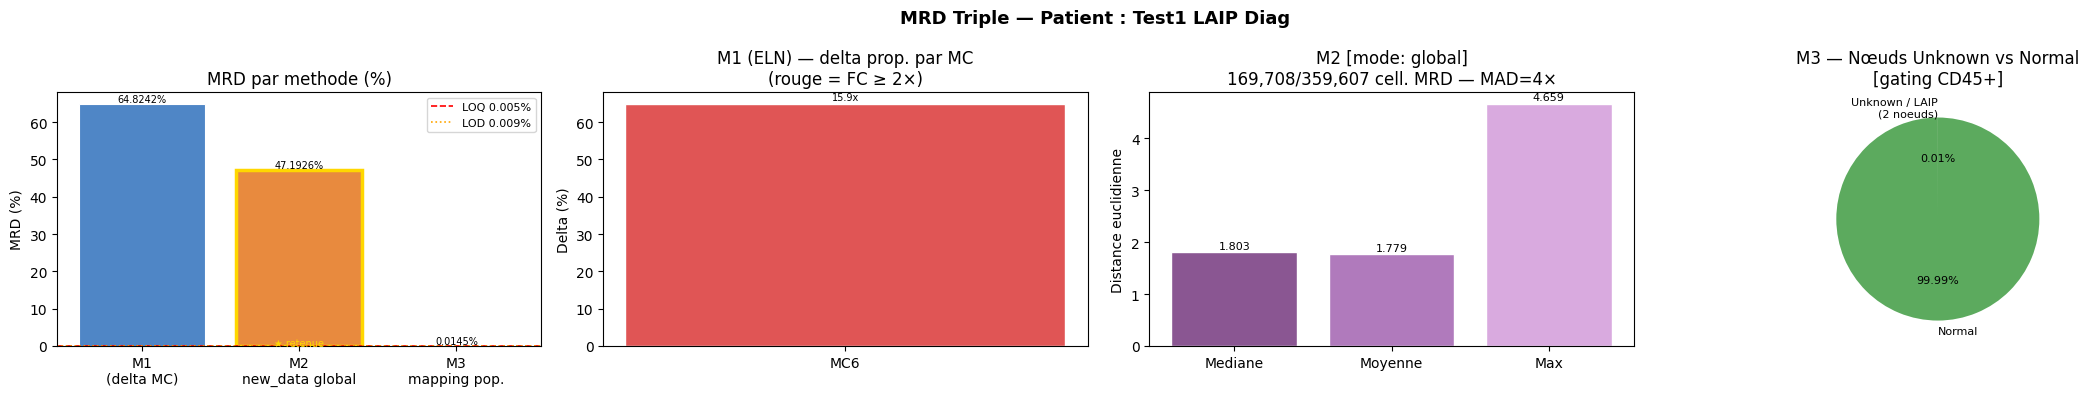

In [20]:
## Cellule 7 — Visualisation graphique des resultats (patient unique)

fig, axes = plt.subplots(1, 4, figsize=(22, 4))
fig.suptitle(f"MRD Triple — Patient : {result['patient_id']}", fontsize=13, fontweight="bold")

def _get_pct(m: dict) -> float:
    return m.get("mrd_pct", m.get("mrd_percent", m.get("mrd_value", 0.0) * 100))

# --- Graphe 1 : comparaison des 3 methodes ---
methods = ["M1\n(delta MC)", "M2\nnew_data global", "M3\nmapping pop."]
values  = [_get_pct(mrd["method_1"]), _get_pct(mrd["method_2"]), _get_pct(mrd["method_3"])]
colors  = ["#4f86c6", "#e88a3e", "#5caa5e"]
bars = axes[0].bar(methods, values, color=colors, edgecolor="white", linewidth=0.8)
axes[0].axhline(0.005, color="red",    linestyle="--", linewidth=1.2, label="LOQ 0.005%")
axes[0].axhline(0.009, color="orange", linestyle=":",  linewidth=1.2, label="LOD 0.009%")
axes[0].set_title("MRD par methode (%)")
axes[0].set_ylabel("MRD (%)")
axes[0].legend(fontsize=8)
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
                 f"{val:.4f}%", ha="center", va="bottom", fontsize=7)
best_m = mrd.get("best_method", "")
if best_m:
    idx_map = {"method_1": 0, "method_2": 1, "method_3": 2}
    if best_m in idx_map:
        bars[idx_map[best_m]].set_edgecolor("#FFD700")
        bars[idx_map[best_m]].set_linewidth(2.5)
        axes[0].text(idx_map[best_m], -0.0008, "★ retenue", ha="center", fontsize=7, color="#FFD700")

# --- Graphe 2 : delta par metacluster M1 (ELN 2022) ---
mc_details = mrd["method_1"].get("mc_mrd_details", {})
mc_fc      = mrd["method_1"].get("mc_fold_changes", {})
if mc_details:
    mc_labels = [f"MC{k}" for k in sorted(mc_details.keys())]
    mc_vals   = [mc_details[k]["delta"] * 100 for k in sorted(mc_details.keys())]
    fc_vals   = [mc_details[k].get("fold_change", 0.0) for k in sorted(mc_details.keys())]
    bar_colors_mc = [
        "#e05555" if mc_details[k].get("fold_change", 0) >= PARAMS["mrd1_fold_change"] else "#5a8fd4"
        for k in sorted(mc_details.keys())
    ]
    b2 = axes[1].bar(mc_labels, mc_vals, color=bar_colors_mc, edgecolor="white")
    for b, fc in zip(b2, fc_vals):
        axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + max(mc_vals)*0.01,
                     f"{fc:.1f}x", ha="center", va="bottom", fontsize=7)
    axes[1].set_title("M1 (ELN) — delta prop. par MC\n(rouge = FC ≥ 2×)")
    axes[1].set_ylabel("Delta (%)")
elif mc_fc:
    mc_labels = [f"MC{k}" for k in sorted(mc_fc.keys())]
    mc_vals   = [mc_fc[k] for k in sorted(mc_fc.keys())]
    bar_cols  = ["#e05555" if v >= PARAMS["mrd1_fold_change"] else "#5a8fd4" for v in mc_vals]
    axes[1].bar(mc_labels, mc_vals, color=bar_cols, edgecolor="white")
    axes[1].axhline(PARAMS["mrd1_fold_change"], color="red", linestyle="--",
                    linewidth=1.2, label=f"seuil x{PARAMS['mrd1_fold_change']}")
    axes[1].set_title("M1 : Fold-change MC (legacy)")
    axes[1].set_ylabel("Fold-change")
    axes[1].legend(fontsize=8)
else:
    axes[1].text(0.5, 0.5, "M1 : aucun MC\ncontributif", ha="center", va="center",
                 transform=axes[1].transAxes, fontsize=9)
    axes[1].set_title("M1 : delta par MC")

# --- Graphe 3 : stats distances M2 (new_data global) ---
dist_stats = mrd["method_2"].get("cell_distances_stats", {})
n_mrd_c    = mrd["method_2"].get("mrd_events", mrd["method_2"].get("n_mrd_cells", 0))
n_total_c  = mrd["method_2"].get("n_cells_patient", result.get("preprocessing", {}).get("n_cells_global", 1))
preproc_m2 = mrd["method_2"].get("preprocessing_mode", "global")
if dist_stats:
    stat_labels = ["Mediane", "Moyenne", "Max"]
    stat_vals   = [dist_stats.get("median", 0), dist_stats.get("mean", 0), dist_stats.get("max", 0)]
    bar_c = axes[2].bar(stat_labels, stat_vals, color=["#8a5692", "#b07abc", "#d9aadf"], edgecolor="white")
    for b, v in zip(bar_c, stat_vals):
        axes[2].text(b.get_x() + b.get_width()/2, b.get_height() * 1.01,
                     f"{v:.3f}", ha="center", va="bottom", fontsize=8)
    mad_a = mrd["method_2"].get("mad_allowed", PARAMS["mad_allowed"])
    axes[2].set_title(f"M2 [mode: {preproc_m2}]\n{n_mrd_c:,}/{n_total_c:,} cell. MRD — MAD={mad_a}×")
    axes[2].set_ylabel("Distance euclidienne")
else:
    axes[2].text(0.5, 0.5, f"M2 [{preproc_m2}]\ndonnees non disponibles",
                 ha="center", va="center", transform=axes[2].transAxes, fontsize=9)
    axes[2].set_title("M2 : Distances cellulaires")

# --- Graphe 4 : repartition Unknown/Normal M3 ---
n_unknown = mrd["method_3"].get("mrd_events", mrd["method_3"].get("n_unknown_cells", 0))
n_total_m3 = result.get("preprocessing", {}).get("n_cells_cd45", result.get("n_cells", 1))
n_normal   = max(0, n_total_m3 - n_unknown)
n_unk_nodes = mrd["method_3"].get("n_unknown_nodes", 0)
labels_m3 = [f"Unknown / LAIP\n({n_unk_nodes} noeuds)", "Normal"]
sizes_m3  = [max(n_unknown, 0), max(n_normal, 0)]
colors_m3 = ["#e05555", "#5caa5e"]
if sum(sizes_m3) > 0:
    axes[3].pie(sizes_m3, labels=labels_m3, colors=colors_m3,
                autopct="%1.2f%%", startangle=90, textprops={"fontsize": 8})
axes[3].set_title("M3 — Nœuds Unknown vs Normal\n[gating CD45+]")

plt.tight_layout()
plt.show()


## Section 3 — Traitement de cohorte (batch)

Traitement de **tous les FCS patients** du dossier `PATHOLOGICAL_FOLDER` en série.

Pour chaque patient :
1. Prétraitement (gating + transformation)
2. Mapping sur le MST NBM
3. Calcul M1 + M2 + M3 en parallèle interne
4. Sélection de la meilleure méthode
5. Export HTML + JSON + CSV Kaluza

**Résultat** : `cohort_df` — DataFrame de synthèse avec une ligne par patient.

In [21]:
## Cellule 8 — Lancement du batch cohorte

fcs_files_batch = sorted(PATHOLOGICAL_FOLDER.glob("*.fcs"))
print(f"Patients a analyser : {len(fcs_files_batch)}")
for f in fcs_files_batch:
    print(f"  {f.name}")

if not fcs_files_batch:
    raise FileNotFoundError(f"Aucun FCS trouve dans : {PATHOLOGICAL_FOLDER}")

# Lance l'analyse de toute la cohorte
# verbose=True affiche la progression patient par patient
cohort_df = run_mrd_batch(
    fcs_file_list = fcs_files_batch,
    nbm           = nbm,
    params        = PARAMS,
    output_dir    = OUTPUT_DIR,
    verbose       = True,
)

print(f"\nCohorte terminee : {len(cohort_df)} patients analyses.")
print(f"Rapports sauvegardes dans : {OUTPUT_DIR}")

Patients a analyser : 1
  Test1 LAIP Diag.fcs
[1/1] Patient Test1 LAIP Diag — Test1 LAIP Diag.fcs ...
[Pipeline] Test1 LAIP Diag | arbre mixte (M1/M3) + new_data (M2)
  [Test1 LAIP Diag.fcs] Tri cellulaire (mode AUTO) — 402,531 cellules brutes
  [Test1 LAIP Diag.fcs]   G1 Débris   →  402,531/ 402,531  (100.0%)  [GMM 2D FSC/SSC]
  [Test1 LAIP Diag.fcs]   G2 Singlets →  359,607/ 402,531  ( 89.3%)  [RANSAC, R²=0.979]
  [Test1 LAIP Diag.fcs]   G3 CD45+    →   27,730/ 402,531  (  6.9%)  [GMM 1D bimodal]
  [Test1 LAIP Diag.fcs]   ✓ Total retenu : 27,730/402,531  (6.9%)
  [Test1 LAIP Diag.fcs] Tri cellulaire (mode AUTO) — 402,531 cellules brutes
  [Test1 LAIP Diag.fcs]   G1 Débris   →  402,531/ 402,531  (100.0%)  [GMM 2D FSC/SSC]
  [Test1 LAIP Diag.fcs]   G2 Singlets →  359,607/ 402,531  ( 89.3%)  [RANSAC, R²=0.979]
  [Test1 LAIP Diag.fcs]   ✓ Total retenu : 359,607/402,531  (89.3%)
  → Arbre mixte NBM+patho (M1/M3) [mode cd45]...


2026-03-06 15:14:08.276 | DEBUG    | flowsom.main:__init__:82 - Reading input.
2026-03-06 15:14:08.281 | DEBUG    | flowsom.main:__init__:84 - Fitting model: clustering and metaclustering.
2026-03-06 15:21:58.977 | DEBUG    | flowsom.main:__init__:86 - Updating derived values.


  → Projection patho sur arbre NBM (M2) [mode global — sans CD45]...
   M1=63.040%  M2=47.193%  M3=0.014%  → method_2 (53%)  ⚠️  DIVERGENCE

 COHORTE — 1 patients analysés
 Récap : C:\Users\flo40\Documents\FlowSomCode\output\mrd_reports\cohort_summary_20260306_152242.csv
 HTML  : C:\Users\flo40\Documents\FlowSomCode\output\mrd_reports
     patient_id  MRD_method_1_pct  MRD_method_2_pct  MRD_method_3_pct best_method  divergence_flag
Test1 LAIP Diag           63.0402           47.1926            0.0144    method_2             True

Cohorte terminee : 1 patients analyses.
Rapports sauvegardes dans : C:\Users\flo40\Documents\FlowSomCode\output\mrd_reports


In [22]:
## Cellule 9 — Tableau de synthese de la cohorte

# Affichage du tableau complet avec formatage
# Note : .applymap() renomme en .map() depuis pandas 2.1
_styler = (cohort_df.style
    .format({
        "MRD_method_1_pct": "{:.4f}%",
        "MRD_method_2_pct": "{:.4f}%",
        "MRD_method_3_pct": "{:.4f}%",
        "n_cells": "{:,}",
        "confidence": "{:.2f}",
    })
    .background_gradient(subset=["MRD_method_1_pct","MRD_method_2_pct","MRD_method_3_pct"],
                          cmap="YlOrRd", vmin=0, vmax=1.0)
    .set_caption("Cohorte MRD Triple — Recapitulatif")
)
if "divergence_flag" in cohort_df.columns:
    _flag_fn = lambda v: "background-color: #ffe0e0" if v else ""
    try:
        _styler = _styler.map(_flag_fn, subset=["divergence_flag"])       # pandas >= 2.1
    except AttributeError:
        _styler = _styler.applymap(_flag_fn, subset=["divergence_flag"])  # pandas < 2.1
display(_styler)

# Export CSV recapitulatif de la cohorte
cohort_csv_path = OUTPUT_DIR / "cohort_summary.csv"
cohort_df.to_csv(cohort_csv_path, index=False)
print(f"\nCSV cohorte sauvegarde : {cohort_csv_path}")

# Export JSON de la cohorte
cohort_json_path = OUTPUT_DIR / "cohort_summary.json"
cohort_df.to_json(cohort_json_path, orient="records", indent=2, force_ascii=False)
print(f"JSON cohorte sauvegarde : {cohort_json_path}")


,patient_id,fcs_file,n_cells,MRD_method_1_pct,MRD_method_2_pct,MRD_method_3_pct,best_method,best_MRD_pct,confidence,divergence_flag,errors,html_report,json_path
0,Test1 LAIP Diag,Test1 LAIP Diag.fcs,"27,730",63.0402%,47.1926%,0.0144%,method_2,47.192600,0.53,True,None,C:\Users\flo40\Documents\FlowSomCode\output\mrd_reports\mrd_report_Test1 LAIP Diag_20260306_152242.html,C:\Users\flo40\Documents\FlowSomCode\output\mrd_reports\mrd_Test1 LAIP Diag_20260306_152242.json



CSV cohorte sauvegarde : C:\Users\flo40\Documents\FlowSomCode\output\mrd_reports\cohort_summary.csv
JSON cohorte sauvegarde : C:\Users\flo40\Documents\FlowSomCode\output\mrd_reports\cohort_summary.json


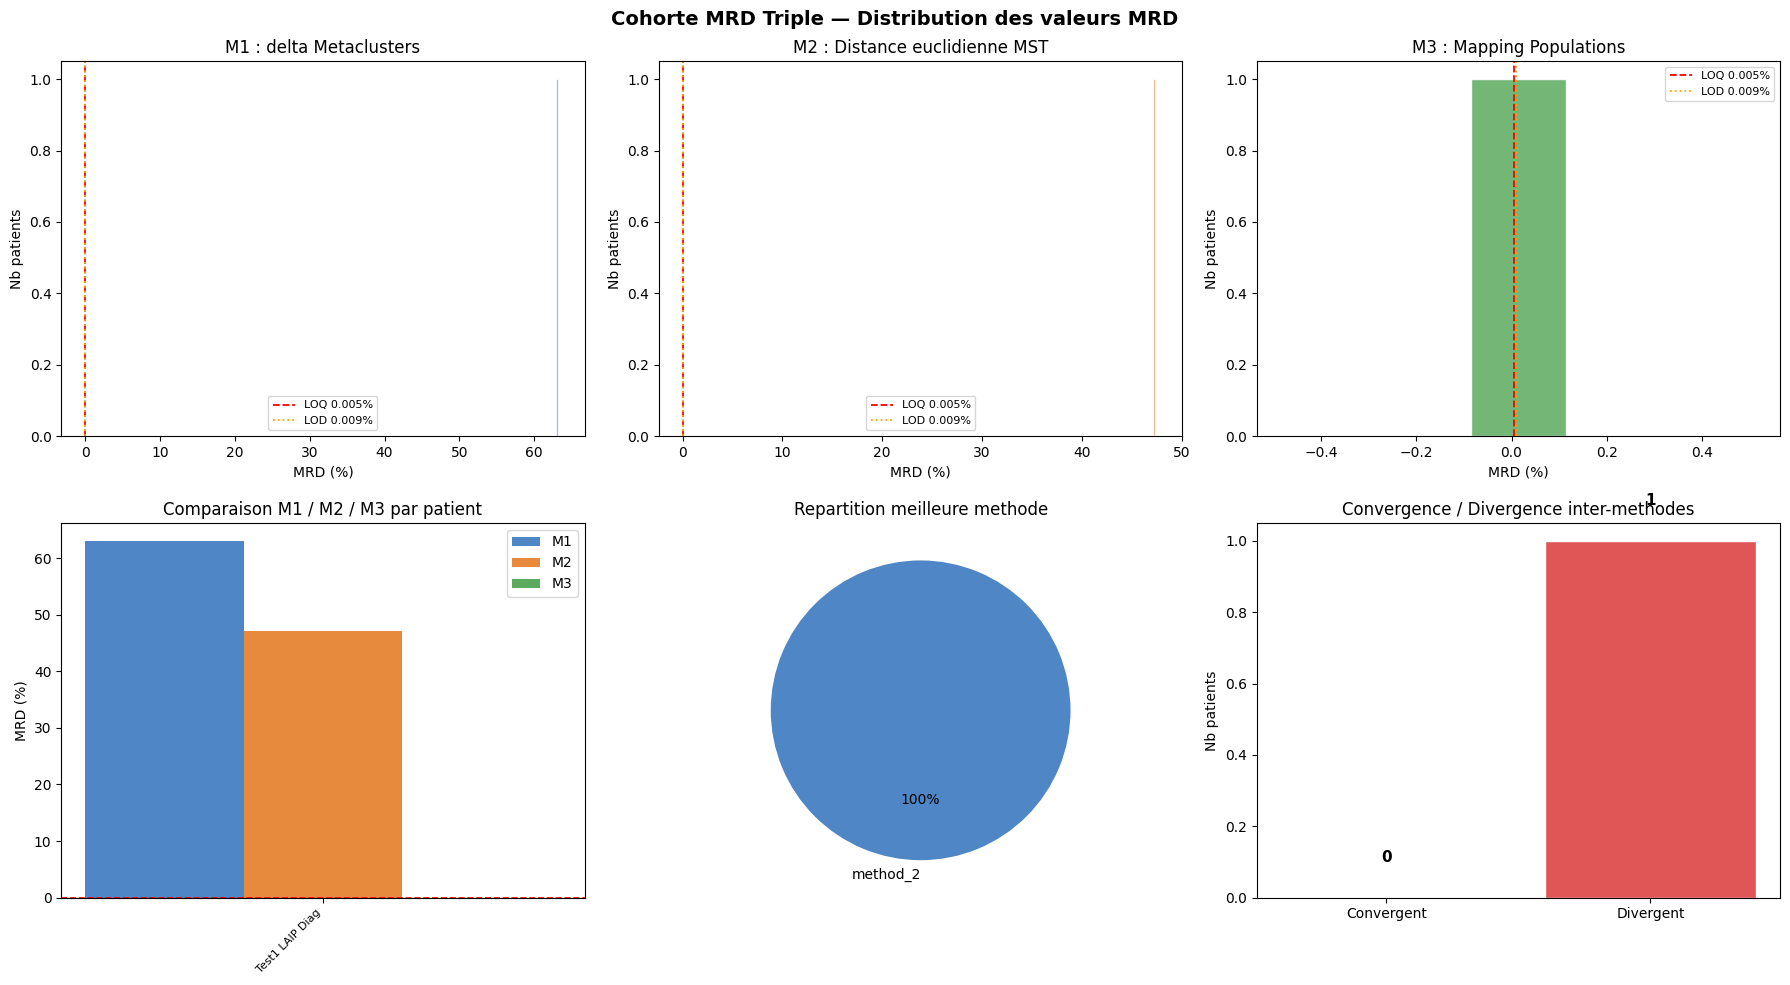

In [23]:
## Cellule 10 — Visualisation statistique de la cohorte

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Cohorte MRD Triple — Distribution des valeurs MRD", fontsize=14, fontweight="bold")

LOQ = PARAMS.get("lod_loq_loq", 0.005)
LOD = PARAMS.get("lod_loq_lod", 0.009)

col_labels = [
    ("MRD_method_1_pct", "M1 : delta Metaclusters", "#4f86c6"),
    ("MRD_method_2_pct", "M2 : Distance euclidienne MST", "#e88a3e"),
    ("MRD_method_3_pct", "M3 : Mapping Populations", "#5caa5e"),
]

# Ligne 1 : histogrammes des valeurs MRD
for ax, (col, title, color) in zip(axes[0], col_labels):
    if col not in cohort_df.columns:
        ax.text(0.5, 0.5, "N/A", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)
        continue
    valid = cohort_df[col].dropna()
    ax.hist(valid, bins=max(5, len(valid)//3), color=color, edgecolor="white", alpha=0.85)
    ax.axvline(LOQ, color="red",    linestyle="--", linewidth=1.3, label=f"LOQ {LOQ}%")
    ax.axvline(LOD, color="orange", linestyle=":",  linewidth=1.3, label=f"LOD {LOD}%")
    ax.set_title(title)
    ax.set_xlabel("MRD (%)")
    ax.set_ylabel("Nb patients")
    ax.legend(fontsize=8)

# Ligne 2 : comparaison des 3 methodes par patient (grouped bar)
ax_compare = axes[1, 0]
if all(c in cohort_df.columns for c in ["MRD_method_1_pct", "MRD_method_2_pct", "MRD_method_3_pct"]):
    x = np.arange(len(cohort_df))
    w = 0.25
    ax_compare.bar(x - w,   cohort_df["MRD_method_1_pct"], w, color="#4f86c6", label="M1")
    ax_compare.bar(x,       cohort_df["MRD_method_2_pct"], w, color="#e88a3e", label="M2")
    ax_compare.bar(x + w,   cohort_df["MRD_method_3_pct"], w, color="#5caa5e", label="M3")
    ax_compare.axhline(LOQ, color="red", linestyle="--", linewidth=1.2)
    ax_compare.set_xticks(x)
    ax_compare.set_xticklabels(cohort_df["patient_id"].tolist(), rotation=45, ha="right", fontsize=8)
    ax_compare.set_title("Comparaison M1 / M2 / M3 par patient")
    ax_compare.set_ylabel("MRD (%)")
    ax_compare.legend()

# Ligne 2 : meilleure methode (camembert)
ax_pie = axes[1, 1]
if "best_method" in cohort_df.columns:
    method_counts = cohort_df["best_method"].value_counts()
    ax_pie.pie(method_counts.values, labels=method_counts.index,
               autopct="%1.0f%%", startangle=90,
               colors=["#4f86c6", "#e88a3e", "#5caa5e", "#aaa", "#ccc"])
    ax_pie.set_title("Repartition meilleure methode")

# Ligne 2 : taux de divergence (barres)
ax_div = axes[1, 2]
if "divergence_flag" in cohort_df.columns:
    n_div    = cohort_df["divergence_flag"].sum()
    n_nodiv  = len(cohort_df) - n_div
    ax_div.bar(["Convergent", "Divergent"], [n_nodiv, n_div],
               color=["#5caa5e", "#e05555"], edgecolor="white")
    ax_div.set_title("Convergence / Divergence inter-methodes")
    ax_div.set_ylabel("Nb patients")
    for idx, val in enumerate([n_nodiv, n_div]):
        ax_div.text(idx, val + 0.1, str(val), ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

In [24]:
## Cellule 11 — Tableau de suivi longitudinal (si plusieurs timepoints par patient)
#
# Si les FCS sont nommes selon le pattern : PatientID_YYYY-MM-DD.fcs
# ou PatientID_TP1.fcs / PatientID_TP2.fcs
# cette cellule regroupe les valeurs MRD par patient et les trace en courbe.

import re

def extract_patient_timepoint(patient_id: str):
    """Extrait patient_base et timepoint depuis le nom de fichier."""
    # Exemples : "Pat01_2024-01-15" ou "Pat01_D0" ou "Pat01_TP1"
    m = re.match(r"^(.+?)[-_](D\d+|TP\d+|\d{4}-\d{2}-\d{2}|\d+)$", patient_id, re.IGNORECASE)
    if m:
        return m.group(1), m.group(2)
    return patient_id, "T0"  # Pas de pattern reconnu -> patient unique sans timepoint

if "patient_id" in cohort_df.columns:
    cohort_df[["patient_base", "timepoint"]] = cohort_df["patient_id"].apply(
        lambda pid: pd.Series(extract_patient_timepoint(pid))
    )

    longitudinal_patients = cohort_df[cohort_df.duplicated("patient_base", keep=False)]["patient_base"].unique()

    if len(longitudinal_patients) > 0:
        print(f"Patients avec suivi longitudinal detectes : {list(longitudinal_patients)}")

        fig, ax = plt.subplots(figsize=(12, 5))
        for pat in longitudinal_patients:
            subset = cohort_df[cohort_df["patient_base"] == pat].sort_values("timepoint")
            if "MRD_method_1_pct" in subset.columns:
                ax.plot(subset["timepoint"], subset["MRD_method_1_pct"],
                        marker="o", label=f"{pat} M1")
        ax.axhline(LOQ, color="red",    linestyle="--", linewidth=1.2, label=f"LOQ {LOQ}%")
        ax.axhline(LOD, color="orange", linestyle=":",  linewidth=1.2, label=f"LOD {LOD}%")
        ax.set_title("Suivi longitudinal MRD (Methode 1)")
        ax.set_xlabel("Timepoint")
        ax.set_ylabel("MRD (%)")
        ax.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("Pas de timepoints detectes dans les noms de fichiers.")
        print("Convention attendue : PatientID_D0.fcs, PatientID_TP1.fcs, PatientID_2024-03-15.fcs")
else:
    print("cohort_df non disponible — executer d'abord la cellule 8.")

Pas de timepoints detectes dans les noms de fichiers.
Convention attendue : PatientID_D0.fcs, PatientID_TP1.fcs, PatientID_2024-03-15.fcs


## Section 4 — Utilitaires et débogage

Cellules optionnelles pour inspecter le modèle NBM, diagnostiquer les prétraitements et visualiser la grille SOM.

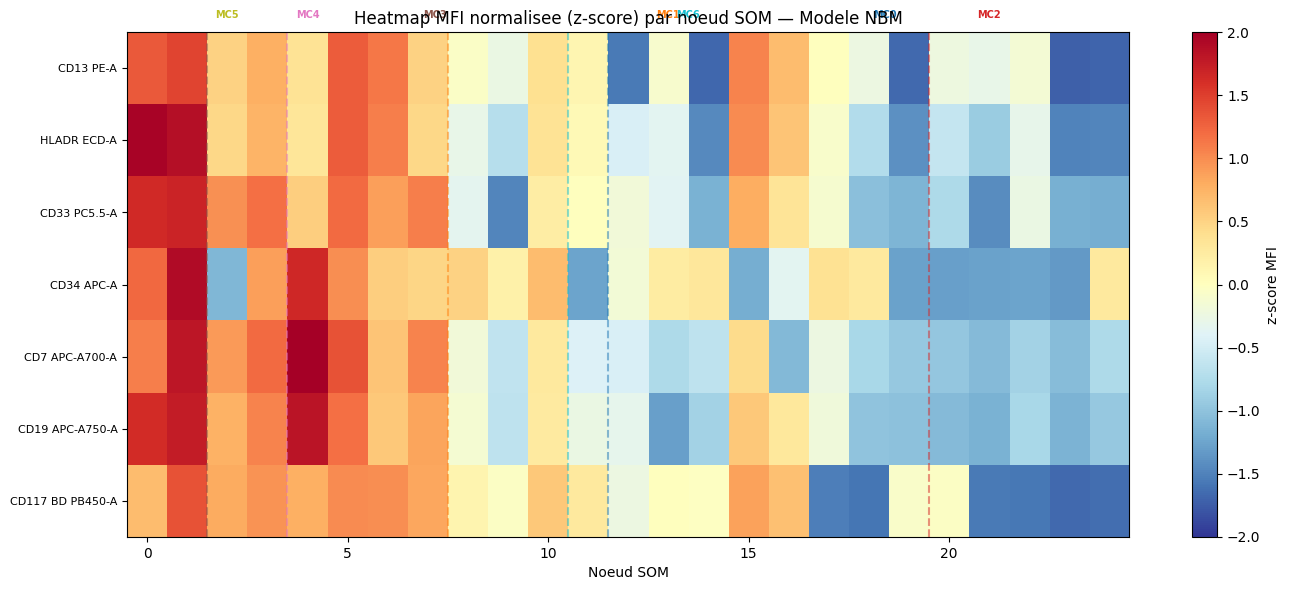

Modele NBM : 25 noeuds x 7 marqueurs
Metaclusters : {0: 5, 1: 5, 2: 3, 3: 6, 4: 1, 5: 3, 6: 2}


In [25]:
## Cellule 12 — Inspection du modele NBM (heatmap MFI)

import matplotlib.pyplot as plt
import numpy as np

# Heatmap des profils d'expression par noeud SOM
fig, ax = plt.subplots(figsize=(max(14, len(nbm.markers) * 0.5), 6))
node_mfi_df = pd.DataFrame(nbm.node_mfi, columns=nbm.markers)

# Normalisation par marqueur pour la lisibilite (z-score)
node_mfi_norm = (node_mfi_df - node_mfi_df.mean()) / (node_mfi_df.std() + 1e-9)

im = ax.imshow(node_mfi_norm.T, aspect="auto", cmap="RdYlBu_r", vmin=-2, vmax=2)
ax.set_yticks(range(len(nbm.markers)))
ax.set_yticklabels(nbm.markers, fontsize=8)
ax.set_xlabel("Noeud SOM")
ax.set_title("Heatmap MFI normalisee (z-score) par noeud SOM — Modele NBM")
plt.colorbar(im, ax=ax, label="z-score MFI")

# Superposer les metaclusters (bandes verticales)
mc_ids = nbm.metaclusters
unique_mc = np.unique(mc_ids)
cmap_mc = plt.cm.get_cmap("tab10", len(unique_mc))
for mc in unique_mc:
    nodes_mc = np.where(mc_ids == mc)[0]
    if len(nodes_mc) > 0:
        ax.axvline(nodes_mc[0] - 0.5, color=cmap_mc(int(mc) % 10),
                   linewidth=1.5, linestyle="--", alpha=0.5)
        ax.text(nodes_mc.mean(), -0.7, f"MC{mc}", ha="center",
                fontsize=7, color=cmap_mc(int(mc) % 10), fontweight="bold")

plt.tight_layout()
plt.show()

print(f"Modele NBM : {nbm.node_mfi.shape[0]} noeuds x {len(nbm.markers)} marqueurs")
print(f"Metaclusters : {dict(zip(*np.unique(mc_ids, return_counts=True)))}")

In [26]:
## Cellule 13 — Diagnostic preprocessing d'un FCS

# Charge un FCS brut et affiche les statistiques de QC avant / apres preprocessing
fcs_diag = fcs_files_patient[0]  # Modifier le fichier si besoin

import flowio, numpy as np

# Lecture brute
with open(fcs_diag, "rb") as f:
    raw = flowio.FlowData(f)

channels = [raw.channels[k]["PnN"] for k in sorted(raw.channels.keys(), key=int)]
data_raw  = np.array(list(raw.events)).reshape(-1, len(channels))

print(f"FCS : {fcs_diag.name}")
print(f"Canaux bruts : {len(channels)} | Cellules brutes : {data_raw.shape[0]:,}")
print(f"Canaux : {channels}")

# Preprocessing
from mrd_pipeline import preprocess_fcs
X_proc, markers_proc, qc = preprocess_fcs(fcs_diag, PARAMS)
print(f"\nApres preprocessing :")
print(f"  Cellules retenues : {X_proc.shape[0]:,}")
print(f"  Marqueurs retenus : {len(markers_proc)}")
print(f"  Marqueurs : {markers_proc}")
print(f"  QC : {qc}")

# Verifier l'absence de NaN
n_nan = int(np.isnan(X_proc).sum())
if n_nan > 0:
    print(f"\n  ATTENTION : {n_nan} valeurs NaN detectees dans la matrice preprocessee !")
else:
    print(f"\n  OK : aucun NaN dans la matrice preprocessee.")

FCS : Test1 LAIP Diag.fcs
Canaux bruts : 26 | Cellules brutes : 402,531
Canaux : ['FSC-H', 'FSC-A', 'SSC-H', 'SSC-A', 'FL1-H', 'FL1-A', 'FL2-H', 'FL2-A', 'FL3-H', 'FL3-A', 'FL4-H', 'FL4-A', 'FL5-H', 'FL5-A', 'FL6-H', 'FL6-A', 'FL7-H', 'FL7-A', 'FL8-H', 'FL8-A', 'FL9-H', 'FL9-A', 'FL10-H', 'FL10-A', 'FSC-Width', 'Time']
  [Test1 LAIP Diag.fcs] Tri cellulaire (mode AUTO) — 402,531 cellules brutes
  [Test1 LAIP Diag.fcs]   G1 Débris   →  402,531/ 402,531  (100.0%)  [GMM 2D FSC/SSC]
  [Test1 LAIP Diag.fcs]   G2 Singlets →  359,607/ 402,531  ( 89.3%)  [RANSAC, R²=0.979]
  [Test1 LAIP Diag.fcs]   G3 CD45+    →   27,888/ 402,531  (  6.9%)  [GMM 1D bimodal]
  [Test1 LAIP Diag.fcs]   ✓ Total retenu : 27,888/402,531  (6.9%)


ValueError: not enough values to unpack (expected 3, got 2)

---

## Notes méthodologiques et références ELN 2022

### Seuils MRD (ELN 2022)
| Paramètre | Valeur | Description |
|-----------|--------|-------------|
| **LOD** | 0.009 % | Limite de détection — en dessous = non quantifiable |
| **LOQ** | 0.005 % | Limite de quantification |
| **Fold-change** | × 2 | Seuil M1 : proportion patient > 2× NBM = positif |
| **Min events/node** | ≥ 17 | Minimum ELN par nœud SOM pour être comptabilisé |
| **Fold-change NBM** | > 1.9 % | Fréquence maximale d'une population en NBM |

### Choix de la meilleure méthode (`select_best_mrd_method`)
- **M1** (delta MC) est préférée quand elle détecte des metaclusters avec FC > 2× et ≥ 17 événements.
- **M2** (distances) est un contrôle croisé : si bimodalité élevée → confirmation M1 ; si diverge → flag.
- **M3** (mapping pop.) est la méthode ELN de référence quand le `pop_mfi_ref` est disponible.
- Si les 3 méthodes divergent (écart > 2 ordres de grandeur), un **flag de divergence** est levé → revue manuelle.

### Format de la table Kaluza
La table CSV générée (`export_kaluza_csv`) contient une ligne par nœud SOM avec :
- `node_id`, `metacluster`, `n_cells`, `pct_of_total`
- `mrd_m1_contributing` — nœud contribuant à la MRD selon M1 (boolean)
- `mrd_m2_deviant` — nœud déviant selon M2 (boolean)
- `mrd_m3_unknown` — nœud Unknown selon M3 (boolean)
- MFI de chaque marqueur (colonnes supplémentaires)

### Références
- Schuurhuis GJ et al. *ELN MRD recommendations*, Blood 2018.
- Döhner H et al. *ELN 2022 recommendations for AML*, Blood 2022.
- Van Gassen S et al. *FlowSOM*, Cytometry A 2015.
- LSCflow ALFA protocol — Tube 1 LAIP, Tube 2 LSC, Tube 3 Monocytes.